Upload the dataset and read it in as a pandas dataframe

In [ ]:
# This uploads the Olympic Medalists 2008 CSV File
from google.colab import files
files.upload()

In [ ]:
# This reads the CSV file into a pandas dataframe and renames it 'medals'
import pandas as pd

medals = pd.read_csv("olympics_08_medalists.csv")

# This allows the user to display a preview of the dataset
display(medals.head())

,medalist_name,male_archery,female_archery,male_athletics,female_athletics,male_badminton,female_badminton,male_baseball,male_basketball,female_basketball,...,female_beach volleyball,male_volleyball,female_volleyball,male_water polo,female_water polo,male_weightlifting,female_weightlifting,male_freestyle wrestling,female_freestyle wrestling,male_greco-roman wrestling
0,Aaron Armstrong,NaN,NaN,gold,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aaron Peirsol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Abdullo Tangriev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Abeer Abdelrahman,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,bronze,NaN,NaN,NaN
4,Abhinav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Data Cleaning & Tidy Process

First we need to reshape the data from its 'untidy' form. Currently, each sport-gender combination is in a separate column. We want to 'melt' the dataframe by converting from wide format into long format using the pandas melt function. We do this by combining those separate sport-gender columns into one single 'Event' column.

In [ ]:
## Data Cleaning & Tidy Process

# This will melt each sport-gender combination from separate columns into a single 'Event' column
melted_medals = pd.melt(medals, id_vars=['medalist_name'], var_name='Event', value_name='Medal')
# Display the new table so the user can see the changes
display(melted_medals.head())

,medalist_name,Event,Medal
0,Aaron Armstrong,male_archery,NaN
1,Aaron Peirsol,male_archery,NaN
2,Abdullo Tangriev,male_archery,NaN
3,Abeer Abdelrahman,male_archery,NaN
4,Abhinav,male_archery,NaN


After displaying the melted data there are many NaN values in the dataset that will prevent the user from being able to do exploratory data analysis so we have to remove the rows containing those values. We'll use the '.dropna' command to do this.

In [ ]:
# Use .dropna to discard any 'None' or 'NaN' values 
melted_medals = melted_medals.dropna(subset=['Medal'])
# Display the new table so the user can see the changes
display(melted_medals.head())

,medalist_name,Event,Medal
177,Bair Badënov,male_archery,bronze
676,Ilario Di Buò,male_archery,silver
682,Im Dong-hyun,male_archery,gold
760,Jiang Lin,male_archery,bronze
920,Lee Chang-hwan,male_archery,gold


Now we need to split the 'Event' column into 'gender' and 'sport' to accurately reflect the data. We will use the .str.split command to do this. The 'Event' column doesn't provide any new information and clutters up the display so we will drop it. We'll use the .drop command to do this.

In [ ]:
# Split 'Event' column into 2 separate ones reflecting 'Gender' and 'Sport' using .str.split

melted_medals[['Gender', 'Sport']] = melted_medals['Event'].str.split('_',expand=True)

# Drop 'Event' column using .drop command
melted_medals= melted_medals.drop(columns=['Event'])

# Display the dataset and it is in Tidy form
display(melted_medals.head())

,medalist_name,Medal,Gender,Sport
177,Bair Badënov,bronze,male,archery
676,Ilario Di Buò,silver,male,archery
682,Im Dong-hyun,gold,male,archery
760,Jiang Lin,bronze,male,archery
920,Lee Chang-hwan,gold,male,archery


Visualizations

The first visualization I'm making is a bar graph that will display the count of each type of medal earned at the 2008 Olympics

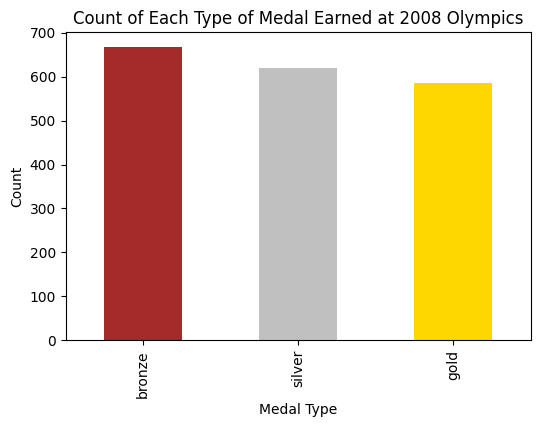

In [ ]:
# This imports matplotlib for plotting
import matplotlib.pyplot as plt

# This counts the number of times each medal type appears in the dataset
medals_counts = melted_medals['Medal'].value_counts()

# This sets the size of the plot for better visibility/ user display
plt.figure(figsize=(6,4))
# creates a bar plot of the medal counts
medals_counts.plot(kind="bar", color=["brown","silver","gold"])
# Axis labels and title
plt.xlabel("Medal Type")
plt.ylabel("Count")
plt.title("Count of Each Type of Medal Earned at 2008 Olympics")
# Displays the plot
plt.show()




The second visualization I'm making is a pie chart that will show the breakdown in what percent of medals earned were by female athletes vs male athletes at the 2008 Olympics

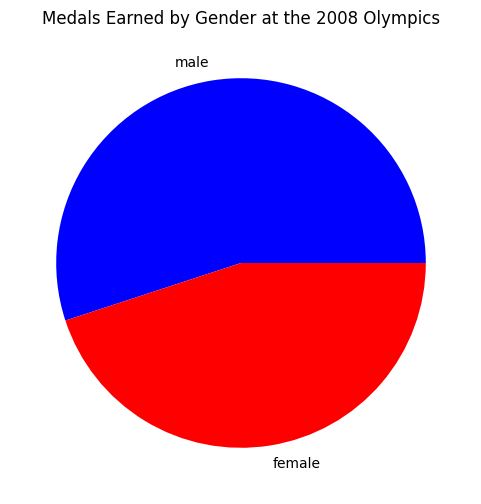

In [ ]:
# This counts how many medals were earned by each gender
gender_counts = melted_medals["Gender"].value_counts()

# This sets the size of the pie chart for better user visiblity
plt.figure(figsize=(6,6))
# Creates the pie chart where the labels are gender categories, 
# percentage labels are added, and custom colors for each gender are added
plt.pie(gender_counts, 
        labels = gender_counts.index, 
        autopct = '%1.1f%%',
        colors=["blue","pink"])
# Sets title
plt.title("Medals Earned by Gender at the 2008 Olympics")
# Displays pie chart
plt.show()

Pivot Table

Next we will create a pivot table to summarize medal counts by sport and medal type. We will use the pivot_table() command to create a summary table where 'index' is the sport, 'columns' are the medal type (Gold, Silver, Bronze), 'values' are the counts of medalist_name, aggfunc is the count/number of medalists, and fill_values = 0 will take care of any missing entries by replacing them with 0.

In [ ]:
# Aggregation of Medals by Sport
pivot_table = melted_medals.pivot_table(index='Sport', columns='Medal', values = 'medalist_name', aggfunc='count',fill_value=0)

# Display
display(pivot_table)

Medal,bronze,gold,silver
Sport,,,
archery,8,5,7
artistic gymnastics,19,14,16
association football,36,37,36
athletics,55,52,59
badminton,7,7,8
baseball,24,24,24
basketball,24,23,24
beach volleyball,4,4,4
bmx,2,2,2
